In [10]:
import pandas as pd
import numpy as np
import pickle
import ast
import re
import emoji
import lightgbm as lgb
from sklearn.feature_extraction.text import TfidfVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import re


# ---------------------------------------------------------
# 1. INITIALISATION & FONCTIONS (OPTIMISÉES)
# ---------------------------------------------------------
analyzer = SentimentIntensityAnalyzer()
hashtag_regex = re.compile(r'#\w+')
mention_regex = re.compile(r'@\w+')
emoji_set = set(emoji.EMOJI_DATA)

# Dictionnaire de slang pré-compilé pour l'analyse de sentiment
ski_slang_map = {"sick": "amazing", "gnarly": "impressive", "insane": "incredible", 
                 "crushing": "performing well", "send it": "go for it", "fail": "funny mistake"}

def get_sentiment(text):
    text = str(text).lower()
    for word, replacement in ski_slang_map.items():
        text = text.replace(word, replacement)
    return analyzer.polarity_scores(text)['compound']

def engineer_features(df, is_train=True, train_df=None):
    df = df.copy()
    
    # 1. Uniformisation ID
    if 'id' in df.columns:
        df = df.rename(columns={'id': 'ID'})
    df['ID'] = df['ID'].astype(str).str.strip()
        
    # 2. Features Texte Rapides
    df['description'] = df['description'].fillna('')
    df['desc_len'] = df['description'].str.len()
    df['word_count'] = df['description'].str.split().str.len()
    df['hashtag_count'] = df['description'].apply(lambda x: len(hashtag_regex.findall(str(x))))
    df['mention_count'] = df['description'].apply(lambda x: len(mention_regex.findall(str(x))))
    df['emoji_count'] = df['description'].apply(lambda x: sum(1 for char in str(x) if char in emoji_set))
    df['sent_compound'] = df['description'].apply(get_sentiment)

    # 3. Features Temporelles
    df['release_year'] = df['release_year'].fillna(df['release_year'].median() if is_train else train_df['release_year'].median())
    df['video_age'] = 2026 - df['release_year']
    
    # EXTRACTION TEMPORELLE ULTRA-RAPIDE (VECTORISÉE SANS BUG)
    df['post_month'] = 6 # Valeur par défaut
    numeric_ids = pd.to_numeric(df['ID'], errors='coerce')
    valid_mask = numeric_ids.notna()
    
    if valid_mask.any():
        # On utilise numpy pour faire le bitshift sur des entiers 64-bits sans erreur
        valid_ints = numeric_ids[valid_mask].values.astype(np.int64)
        shifted = np.right_shift(valid_ints, 32)
        
        # pd.to_datetime sur un array renvoie un DatetimeIndex (qui utilise .month directement)
        dates = pd.to_datetime(shifted, unit='s', errors='coerce')
        df.loc[valid_mask, 'post_month'] = dates.month

    # On sécurise les éventuelles valeurs manquantes avec 6 et on force en entier
    df['post_month'] = df['post_month'].fillna(6).astype(int)

    # 4. Autres Features
    df['artist_count'] = df['artists'].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) and str(x).startswith('[') else 1)
    df['is_optimal_duration'] = df['video_duration'].between(6, 12).astype(int) if 'video_duration' in df.columns else 0
    df['is_minimalist'] = (df['desc_len'] <= 20).astype(int)
    df['is_val_thorens'] = df['channel'].str.contains('Val Thorens', na=False, case=False).astype(int)

    # 5. Target Encoding Lissé (Channel Authority)
    if is_train and 'popularity' in df.columns:
        alpha = 5.0
        global_mean = np.log1p(df['popularity']).mean()
        channel_stats = df.groupby('channel')['popularity'].agg(
             sum_log=lambda x: np.log1p(x).sum(), count='count'
        )
        channel_stats['channel_authority'] = (channel_stats['sum_log'] + alpha * global_mean) / (channel_stats['count'] + alpha)
        df = df.merge(channel_stats[['channel_authority']], on='channel', how='left')
        df['channel_authority'] = df['channel_authority'].fillna(global_mean)
        
    elif not is_train and train_df is not None:
        channel_authority_map = train_df.groupby('channel')['channel_authority'].first()
        df['channel_authority'] = df['channel'].map(channel_authority_map).fillna(train_df['channel_authority'].mean())
    else:
        df['channel_authority'] = 0

    return df

# ---------------------------------------------------------
# 2. CHARGEMENT TEXTE/CSV DE BASE
# ---------------------------------------------------------
print("Chargement des données de base...")
X_train = pd.read_csv('X_train.csv', sep=';', skipinitialspace=True).rename(columns=lambda x: x.strip())
y_train = pd.read_csv('y_train.csv', sep=';', skipinitialspace=True).rename(columns=lambda x: x.strip())
X_test = pd.read_csv('X_test.csv', sep=';', skipinitialspace=True).rename(columns=lambda x: x.strip())

for df in [X_train, y_train, X_test]:
    if 'id' in df.columns: df.rename(columns={'id': 'ID'}, inplace=True)
    df['ID'] = df['ID'].astype(str).str.strip()

train_data = X_train.merge(y_train, on='ID', how='inner')
train_data = engineer_features(train_data, is_train=True)
test_data = engineer_features(X_test, is_train=False, train_df=train_data)

# TF-IDF
print("Vectorisation TF-IDF...")
tfidf = TfidfVectorizer(max_features=100, stop_words='english', ngram_range=(1,2))
tfidf_cols = [f'tfidf_{col}' for col in tfidf.fit(train_data['description']).get_feature_names_out()]

tfidf_train = pd.DataFrame(tfidf.transform(train_data['description']).toarray(), columns=tfidf_cols, index=train_data.index)
tfidf_test = pd.DataFrame(tfidf.transform(test_data['description']).toarray(), columns=tfidf_cols, index=test_data.index)

train_data = pd.concat([train_data, tfidf_train], axis=1)
test_data = pd.concat([test_data, tfidf_test], axis=1)

# ---------------------------------------------------------
# 3. CHARGEMENT ET FUSION DES MODALITÉS
# ---------------------------------------------------------
print("Chargement des données multimodales...")
df_audio = pd.read_csv('audio_features_ready.csv').rename(columns=lambda x: x.strip())
df_visual = pd.read_csv('features_visual2.csv').rename(columns=lambda x: x.strip())
df_objects = pd.read_csv('object_detection_features.csv').rename(columns=lambda x: x.strip())

with open('embeddings_video.pkl', 'rb') as f:
    df_emb = pd.DataFrame.from_dict(pickle.load(f), orient='index')
    df_emb.columns = [f'emb_{i}' for i in range(df_emb.shape[1])]
    df_emb.index.name = 'ID'
    df_emb.reset_index(inplace=True)

# Nettoyage IDs multimodaux
for df in [df_audio, df_visual, df_emb]:
    id_col = [c for c in df.columns if c.lower() == 'id']
    if id_col: df.rename(columns={id_col[0]: 'ID'}, inplace=True)
    df['ID'] = df['ID'].astype(str).str.strip()

if 'video_id' in df_objects.columns:
    df_objects['ID'] = df_objects['video_id'].astype(str).str.replace('VIDEO_', '', regex=False)
    df_objects.drop(columns=['video_id'], inplace=True)
else:
    df_objects.rename(columns={df_objects.columns[0]: 'ID'}, inplace=True)
    df_objects['ID'] = df_objects['ID'].astype(str).str.replace('VIDEO_', '', regex=False)
df_objects['ID'] = df_objects['ID'].astype(str).str.strip()

def merge_multimodal(df_base):
    res = df_base.merge(df_audio, on='ID', how='left')
    res = res.merge(df_visual, on='ID', how='left')
    res = res.merge(df_objects, on='ID', how='left')
    res = res.merge(df_emb, on='ID', how='left')
    return res

train_full = merge_multimodal(train_data)
test_full = merge_multimodal(test_data)

# ---------------------------------------------------------
# 4. PRÉPARATION LIGHTGBM
# ---------------------------------------------------------
print("Préparation des données pour LightGBM...")
y_train_log = np.log1p(train_full['popularity'])

cols_to_drop = ['ID', 'popularity', 'description', 'artists', 'release_year', 
                'filepath', 'download_timing', 'uploader', 'uploader_short', 'vid', 'uid']
features = [c for c in train_full.columns if c not in cols_to_drop]

X_train_final = train_full[features].copy()
X_test_final = test_full[features].copy()

# Traitement des catégories pour LightGBM (Crucial pour la performance)
cat_features = X_train_final.select_dtypes(include=['object', 'string']).columns.tolist()

for col in cat_features:
    X_train_final[col] = X_train_final[col].fillna('Unknown').astype('category')
    # On s'assure que le test a les mêmes catégories que le train
    X_test_final[col] = pd.Categorical(X_test_final[col].fillna('Unknown'), categories=X_train_final[col].cat.categories)

# ---------------------------------------------------------
# 5. ENTRAÎNEMENT & PRÉDICTION LIGHTGBM
# ---------------------------------------------------------
print(f"Entraînement de LightGBM ({X_train_final.shape[1]} features)...")

# Paramètres optimisés pour des données bruitées et de grande dimension
# Paramètres optimisés pour "Peu de lignes / Énormément de colonnes"
model = lgb.LGBMRegressor(
    n_estimators=500,           # On réduit le nombre d'arbres (1500 c'était trop)
    learning_rate=0.04,
    max_depth=5,                # Arbres beaucoup moins profonds
    num_leaves=15,              # Moins de feuilles pour éviter de couper les données en trop petits morceaux
    min_child_samples=20,       # OBLIGATOIRE : exige au moins 20 lignes par feuille
    subsample=0.8,
    colsample_bytree=0.3,       # TRÈS IMPORTANT : ne prend que 30% des 2200 features par arbre pour forcer le modèle à chercher partout
    reg_alpha=0.5,              # Régularisation L1 (tue le bruit)
    reg_lambda=1.0,             # Régularisation L2
    random_state=42,
    n_jobs=-1
)

# On remplace tous les caractères "interdits" par des underscores (_)
X_train_final = X_train_final.rename(columns=lambda x: re.sub(r'[^A-Za-z0-9_]', '_', x))
X_test_final = X_test_final.rename(columns=lambda x: re.sub(r'[^A-Za-z0-9_]', '_', x))

# Et on lance l'entraînement !
model.fit(X_train_final, y_train_log)

print("Génération des prédictions Test...")
preds_log = model.predict(X_test_final)

preds = np.expm1(preds_log)
preds = np.clip(preds, 0, None)

submission = pd.DataFrame({
    'ID': test_full['ID'],
    'popularity': preds
})

submission.to_csv('submission_lightgbm_multimodal.csv', index=False)
print(f"✅ Fichier généré avec succès ! Nombre de lignes : {len(submission)}")

Chargement des données de base...
Vectorisation TF-IDF...
Chargement des données multimodales...
Préparation des données pour LightGBM...
Entraînement de LightGBM (2223 features)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052735 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 530434
[LightGBM] [Info] Number of data points in the train set: 1348, number of used features: 2200
[LightGBM] [Info] Start training from score 2.157521
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Génération des prédictions Test...
✅ Fichier généré avec succès ! Nombre de lignes : 338


--- ÉVALUATION LOCALE (5-FOLD CV) ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.098563 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 529938
[LightGBM] [Info] Number of data points in the train set: 1078, number of used features: 2198
[LightGBM] [Info] Start training from score 2.161196
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

/var/folders/xn/84fm85ps279_8td48hs0pfhr0000gq/T/ipykernel_11178/2497044004.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Value", y="Feature", data=feature_imp.head(20), palette="viridis")


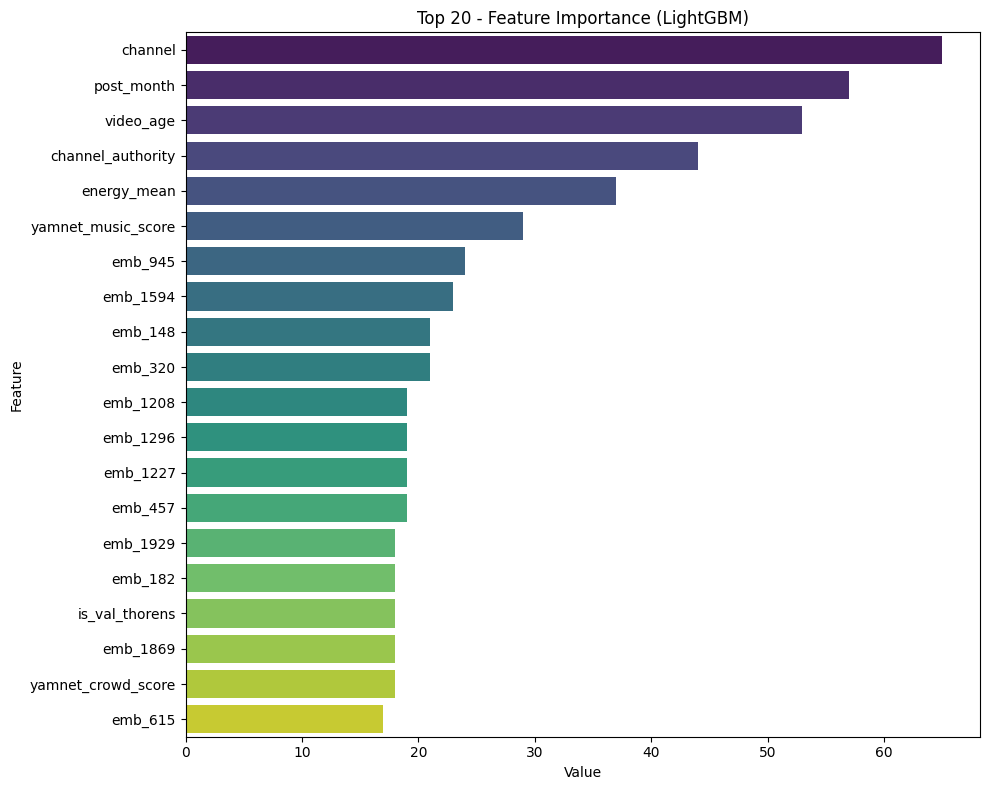

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

print("--- ÉVALUATION LOCALE (5-FOLD CV) ---")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = []

# On va tester le modèle 5 fois sur des morceaux différents
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_final)):
    X_tr, y_tr = X_train_final.iloc[train_idx], y_train_log.iloc[train_idx]
    X_va, y_va = X_train_final.iloc[val_idx], y_train_log.iloc[val_idx]
    
    # Entraînement silencieux
    model.fit(X_tr, y_tr, callbacks=[lgb.log_evaluation(period=0)])
    
    # Prédiction et calcul de l'erreur (CORRIGÉ ICI)
    preds_val = model.predict(X_va)
    rmse = np.sqrt(mean_squared_error(y_va, preds_val))
    rmse_scores.append(rmse)
    print(f"Fold {fold+1} - RMSE: {rmse:.4f}")

print(f"✅ RMSE Moyen Local : {np.mean(rmse_scores):.4f} (Plus c'est bas, meilleur c'est !)")

# --- FEATURE IMPORTANCE ---
print("\n--- TOP 20 DES VARIABLES LES PLUS IMPORTANTES ---")
# On ré-entraîne une dernière fois sur tout
model.fit(X_train_final, y_train_log, callbacks=[lgb.log_evaluation(period=0)])

# Création du graphique
feature_imp = pd.DataFrame({
    'Value': model.feature_importances_,
    'Feature': X_train_final.columns
}).sort_values(by="Value", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x="Value", y="Feature", data=feature_imp.head(20), palette="viridis")
plt.title('Top 20 - Feature Importance (LightGBM)')
plt.tight_layout()
plt.show()